# 1. Import Libraries

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



# 2. Load Raw data

In [66]:
df = pd.read_csv('diabetes_dataset.csv')
print("Raw data loaded!")
print("Rows:", len(df), "| Columns:", len(df.columns))
print("Shape:", df.shape)

Raw data loaded!
Rows: 768 | Columns: 9
Shape: (768, 9)


# 3. First Look at the Data

In [67]:
#Tells us the number of rows and columns
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [68]:
# Show all column names
print("Column names:")
print(list(df.columns))

Column names:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


In [69]:
print("Data types:")
print(df.dtypes)

Data types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object


In [70]:
df[df.select_dtypes("int").columns] = df.select_dtypes("int").astype(float)

In [71]:
print("Data types:")
print(df.dtypes)

Data types:
Pregnancies                 float64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                         float64
Outcome                     float64
dtype: object


# 4.Check Missing Values

In [72]:
# Count missing/empty values in every column
missing = df.isnull().sum()

print("Missing values in each column:")
print(missing)

print("\nTotal missing values:", missing.sum())

Missing values in each column:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Total missing values: 0


# 5. Duplicate Rows

In [73]:
duplicate_rows = df.duplicated().sum()

print("Number of completely duplicated rows:", duplicate_rows)

Number of completely duplicated rows: 0


# 6. Validation 

In [74]:
df['Pregnancies'] = pd.to_numeric(df['Pregnancies'], errors='coerce')
df['Glucose'] = pd.to_numeric(df['Glucose'], errors='coerce')
df['BloodPressure'] = pd.to_numeric(df['BloodPressure'], errors='coerce')
df['SkinThickness'] = pd.to_numeric(df['SkinThickness'], errors='coerce')
df['Insulin'] = pd.to_numeric(df['Insulin'], errors='coerce')
df['BMI'] = pd.to_numeric(df['BMI'], errors='coerce')
df['DiabetesPedigreeFunction'] = pd.to_numeric(df['DiabetesPedigreeFunction'], errors='coerce')
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')


before = len(df)

df = df[df['Pregnancies'] > 0]
df = df[df['Glucose'] > 0]
df = df[df['BloodPressure'] > 0]
df = df[df['SkinThickness'] > 0]
df = df[df['Insulin'] > 0]
df = df[df['BMI'] > 0]
df = df[df['DiabetesPedigreeFunction'] > 0]
df = df[df['Age'] > 0]

after = len(df)

print("Bad rows removed:", before - after)
print("Clean rows left:", after)

Bad rows removed: 432
Clean rows left: 336


# 7. Correlation Heatmap

The heatmap shows the correlation between numerical columns.

- Positive value → variables move in the same direction
- Negative value → variables move in opposite directions
- Near 0 → weak linear relationship

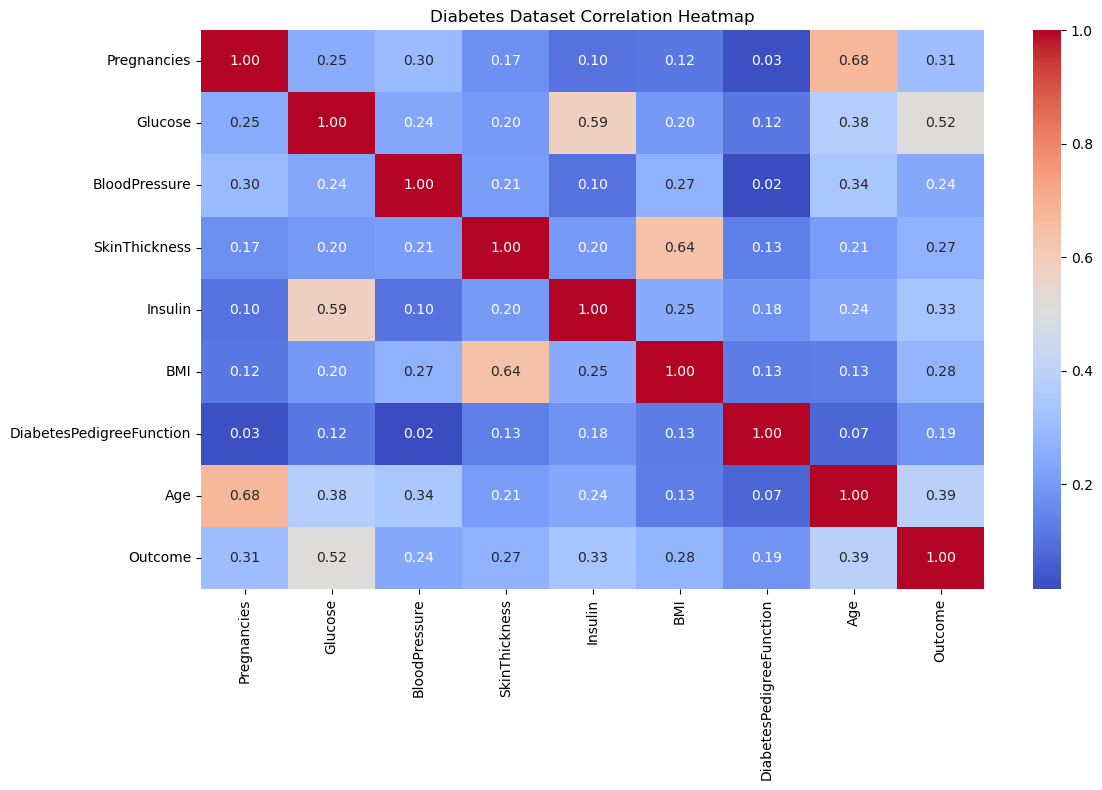

In [75]:
correlation = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Diabetes Dataset Correlation Heatmap")
plt.tight_layout()
plt.show()

# 8. Choose X and Y

In [76]:
X = df[[
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]]

y = df["Outcome"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (336, 8)
y shape: (336,)


In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 268
Testing rows: 68


In [78]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [79]:
y_pred1 = model1.predict(X_test)
score1 = r2_score(y_test, y_pred1)

print("Model 1 (outcome prediction)")
print("R² Score:", round(score1, 4))

Model 1 (outcome prediction)
R² Score: 0.3663


In [80]:
X2 = df[[
    "Pregnancies",
        "Glucose",
        "Insulin",
        "BMI",
        "DiabetesPedigreeFunction",
        "Age"
]]

y2 = df['Outcome']

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

score2 = r2_score(y_test2, y_pred2)

print("Model 2 (Outcome Prediction)")
print("R² Score:", round(score2, 4))

Model 2 (Outcome Prediction)
R² Score: 0.3647


In [81]:
comparison = pd.DataFrame({
    'Model': [
        'Model 1 (8 Features)',
        'Model 2 (6 Features)'
    ],
    'Features Used': [
        'Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age',
        'Pregnancies, Glucose, Insulin, BMI, DiabetesPedigreeFunction, Age'
    ],
    'R2 Score': [
        round(score1, 4),
        round(score2, 4)
    ]
})

comparison

,Model,Features Used,R2 Score
0,Model 1 (8 Features),"Pregnancies, Glucose, BloodPressure, SkinThick...",0.3663
1,Model 2 (6 Features),"Pregnancies, Glucose, Insulin, BMI, DiabetesPe...",0.3647


In [82]:
X.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0
6,3.0,78.0,50.0,32.0,88.0,31.0,0.248,26.0
8,2.0,197.0,70.0,45.0,543.0,30.5,0.158,53.0
13,1.0,189.0,60.0,23.0,846.0,30.1,0.398,59.0
14,5.0,166.0,72.0,19.0,175.0,25.8,0.587,51.0


In [83]:
y.head()

3     0.0
6     1.0
8     1.0
13    1.0
14    1.0
Name: Outcome, dtype: float64

# Creating the Decision Tree

In [84]:
from sklearn.tree import DecisionTreeClassifier, plot_tree 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import ( accuracy_score,
    confusion_matrix,
    classification_report
) 

#Train one Decision Tree 

In [85]:
tree = DecisionTreeClassifier() 
tree.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [86]:
X.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age'],
      dtype='object')

#Predict New Patient

In [87]:
new_patient = [[6, 148, 72, 35, 0, 33.6, 0.627, 50]]
tree.predict(new_patient)

c:\Users\gaded\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1.])

#Predict New Patient2

In [88]:
new_patient2 = [[1, 85, 66, 29, 0, 26.6, 0.351, 31]]
tree.predict(new_patient2)

c:\Users\gaded\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([0.])